In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM 

In [3]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x79cd847a2b90>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x79cd84620a60>, root_client=<openai.OpenAI object at 0x79cd8d3310c0>, root_async_client=<openai.AsyncOpenAI object at 0x79cd847a2bc0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the search tools

In [4]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults

arxiv_search = ArxivQueryRun()
tavily_tool = TavilySearchResults(max_results=5)

tools = [arxiv_search, tavily_tool]


### Defining the Graph state

In [5]:
from typing import TypedDict, Annotated, List, Union
from IPython.display import Image, display

In [6]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    input: str
    agent_outcome: Union[AnyMessage, None]
    chat_history: Annotated[list[AnyMessage], add_messages]

### Initialising the workflow(graph)

In [7]:
from langgraph.graph import StateGraph
workflow = StateGraph(AgentState)

### Defining the agent (node) 

In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableConfig

def research_agent(data, config:RunnableConfig):
    print("----research node----")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI research assistant chatbot,"
                " Use the appropriate search tools to progress towards finding the relevant results."
                " Once you have the relevant search results, summarise them to answer the user query."
                "\nYou have access to the following search tools: {tool_names}."
            ),
            (
                "human",
                "\nUser Query: {input}"
            ),
            
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    agent = prompt | llm.bind_tools(tools)
    result = agent.invoke(data, config=config)
    return {'agent_outcome': [result],
            'chat_history': [result]}

In [9]:
from langgraph.graph import END, StateGraph
workflow = StateGraph(AgentState)

workflow.add_node("research", research_agent)
workflow.set_entry_point("research")

In [10]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        print("----tool calling----")
        message = inputs["agent_outcome"][-1]

        outputs = []
        for tool_call in message.tool_calls:
            print(f"---- Calling {tool_call['name']} with args: {tool_call['args']} ----")
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {
                "agent_outcome": outputs,
                "chat_history": outputs
            }

tool_node = BasicToolNode(tools=tools)
workflow.add_node("tools", tool_node)

In [11]:
def route_tools(
    state: AgentState,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    print("----router----")
    if isinstance(state, list):
        ai_message = state[-1]
    elif agent_outcome := state.get("agent_outcome", []):
        ai_message = agent_outcome[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [12]:
workflow.add_conditional_edges(
    "research",
    route_tools,
    {"tools": "tools", END: END}
)

In [13]:
workflow.add_edge("tools", "research")

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

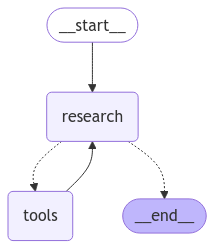

In [15]:
app = workflow.compile(checkpointer=memory)
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [16]:
from langchain_core.messages import HumanMessage, AIMessage
inputs = {
    "input": "What are Small Language Models?",
}

config = {
    "configurable": {
        "thread_id": "1",
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])

for step in app.stream(inputs, config=config, stream_mode="values"):
    try:
        for msg in step['agent_outcome']:
            msg.pretty_print()
    except:
        HumanMessage(inputs["input"]).pretty_print()

================================ Human Message =================================

What are Small Language Models?
----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_ZYFOGTh2DCnnwTqYBThhDl6G)
 Call ID: call_ZYFOGTh2DCnnwTqYBThhDl6G
  Args:
    query: Small Language Models
----tool calling----
---- Calling arxiv with args: {'query': 'Small Language Models'} ----
================================= Tool Message =================================
Name: arxiv

"Published: 2022-01-26\nTitle: An Assessment of the Impact of OCR Noise on Language Models\nAuthors: Konstantin Todorov, Giovanni Colavizza\nSummary: Neural language models are the backbone of modern-day natural language\nprocessing applications. Their use on textual heritage collections which have\nundergone Optical Character Recognition (OCR) is therefore also increasing.\nNevertheless, our understanding of the impact OCR noise could have on la

### Streaming Tokens

Various node level updates (**events**) can be streamed using [`.astream_events`](https://langchain-ai.github.io/langgraph/concepts/streaming/#streaming-llm-tokens-and-events-astream_events).

**Event** is a `dict` object. The important keys are:
1. `event`: type of event that is being emitted. 
2. `name`: name of the vent.
3. `data`: data associated with the event.
4. `metadata`: contains the `langgraph_node`. 



In [17]:
from langchain_core.messages import HumanMessage

inputs = {
    "input": "What are Small Language Models?",
}

config = {
    "configurable": {
        "thread_id": "2",
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])

state = AgentState(**inputs)
async for event in app.astream_events(input=state, config=config, version='v2'):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={})}}, 'name': 'LangGraph', 'tags': [], 'run_id': '22b0fe94-87a1-4a59-b24b-170b230b0721', 'metadata': {'thread_id': '2'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={})}}, 'name': '__start__', 'tags': ['graph:step:0', 'langsmith:hidden'], 'run_id': 'eb21502c-9b1c-45a1-87b0-6d4b8f6147f1', 'metadata': {'thread_id': '2', 'langgraph_step': 0, 'langgraph_node': '__start__', 'langgraph_triggers': ['__start__'], 'langgraph_path': ('__pregel_pull', '__start__'), 'langgraph_checkpoint_ns': '__start__:91c19865-37df-a4e8-707c-c470c94eb82e'}, 'parent_ids': ['22b0fe94-87a1-4a59-b24b-170b230b0721']}
{'event': 'on_chain_start'

#### What all is stremed for an event?

In [18]:
event.keys()

dict_keys(['event', 'data', 'run_id', 'name', 'tags', 'metadata', 'parent_ids'])

##### Digging deep in each of the keys.

In [19]:
async for event in app.astream_events(input=state, config=config, version='v2'):
    print(event['event'])

on_chain_start
on_chain_start
on_chain_start
on_chain_end
on_chain_start
on_chain_end
on_chain_stream
on_chain_end
on_chain_start
----research node----
on_chain_start
on_prompt_start
on_prompt_end
on_chat_model_start
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_end
on_chain_end
on_chain_start
on_chain_end
on_chain_start
----router----
on_chain_end
on_chain_stream
on_chain_end
on_chain_stream
on_chain_start
----tool calling----
---- Calling tavily_search_results_json with args: {'query': 'Small Language Models'} ----
on_chain_start
on_chain_end
on_chain_stream
on_chain_end
on_chain_stream
on_chain_start
----research node----
on_chain_start
on_prompt_start
on_prompt_end
on_chat_model_start
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_stream
on_chat_model_strea

In [20]:
async for event in app.astream_events(input=state, config=config, version='v2'):
    print(event['data'])

{'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={}, id='bb785145-8e95-4e9f-91f4-94864c1d5eaf')}}
{'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={}, id='bb785145-8e95-4e9f-91f4-94864c1d5eaf')}}
{'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={}, id='bb785145-8e95-4e9f-91f4-94864c1d5eaf')}}
{'output': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additional_kwargs={}, response_metadata={}, id='bb785145-8e95-4e9f-91f4-94864c1d5eaf')}, 'input': {'input': 'What are Small Language Models?', 'chat_history': HumanMessage(content='What are Small Language Models?', additiona

This is agent state associated with the event.

In [21]:
async for event in app.astream_events(input=state, config=config, version='v2'):
    print(event['name'])

LangGraph
__start__
_write
_write
_write
_write
__start__
__start__
research
----research node----
RunnableSequence
ChatPromptTemplate
ChatPromptTemplate
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
ChatOpenAI
RunnableSequence
_write
_write
route_tools
----router----
route_tools
research
research
LangGraph
LangGraph


In [22]:
async for event in app.astream_events(input=state, config=config, version='v2'):
    print(event['metadata'])

{'thread_id': '2'}
{'thread_id': '2', 'langgraph_step': 16, 'langgraph_node': '__start__', 'langgraph_triggers': ['__start__'], 'langgraph_path': ('__pregel_pull', '__start__'), 'langgraph_checkpoint_ns': '__start__:c9f2f1cc-ba4e-d946-c294-3e7591112f17'}
{'thread_id': '2', 'langgraph_step': 16, 'langgraph_node': '__start__', 'langgraph_triggers': ['__start__'], 'langgraph_path': ('__pregel_pull', '__start__'), 'langgraph_checkpoint_ns': '__start__:c9f2f1cc-ba4e-d946-c294-3e7591112f17'}
{'thread_id': '2', 'langgraph_step': 16, 'langgraph_node': '__start__', 'langgraph_triggers': ['__start__'], 'langgraph_path': ('__pregel_pull', '__start__'), 'langgraph_checkpoint_ns': '__start__:c9f2f1cc-ba4e-d946-c294-3e7591112f17'}
{'thread_id': '2', 'langgraph_step': 16, 'langgraph_node': '__start__', 'langgraph_triggers': ['__start__'], 'langgraph_path': ('__pregel_pull', '__start__'), 'langgraph_checkpoint_ns': '__start__:c9f2f1cc-ba4e-d946-c294-3e7591112f17'}
{'thread_id': '2', 'langgraph_step': 

#### Filtered event info

In [23]:

config = {
    "configurable": {
        "thread_id": "3",
    }
}

async for event in app.astream_events(input=state, config=config, version='v2'):
    print(f"Node: {event['metadata'].get('langgraph_node')}. Type: {event['event']}. Name: {event['name']}")

Node: None. Type: on_chain_start. Name: LangGraph
Node: __start__. Type: on_chain_start. Name: __start__
Node: __start__. Type: on_chain_start. Name: _write
Node: __start__. Type: on_chain_end. Name: _write
Node: __start__. Type: on_chain_start. Name: _write
Node: __start__. Type: on_chain_end. Name: _write
Node: __start__. Type: on_chain_stream. Name: __start__
Node: __start__. Type: on_chain_end. Name: __start__
Node: research. Type: on_chain_start. Name: research
----research node----
Node: research. Type: on_chain_start. Name: RunnableSequence
Node: research. Type: on_prompt_start. Name: ChatPromptTemplate
Node: research. Type: on_prompt_end. Name: ChatPromptTemplate
Node: research. Type: on_chat_model_start. Name: ChatOpenAI
Node: research. Type: on_chat_model_stream. Name: ChatOpenAI
Node: research. Type: on_chat_model_stream. Name: ChatOpenAI
Node: research. Type: on_chat_model_stream. Name: ChatOpenAI
Node: research. Type: on_chat_model_stream. Name: ChatOpenAI
Node: research. 

**Tokens** will be generated during `on_chain_stream` event. And it will be generated by the researcher and tools node.

In [24]:

inputs = {
    "input": "How are LLMs different from Small Language Models?",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
state = AgentState(**inputs)

config = {
    "configurable": {
        "thread_id": "4",
    }
}
nodes_to_stream = ["research", "tools"]
async for event in app.astream_events(input=state, config=config, version='v2'):
    if event['event'] == "on_chat_model_stream" and event['metadata'].get('langgraph_node', '') in nodes_to_stream:
        print(event["data"])

----research node----
{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='run-0903fbf4-43a4-4b8f-8fb5-afff7c54b130')}
{'chunk': AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_4YeZyuM050H7xkwLTcLFuUHJ', 'function': {'arguments': '', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={}, id='run-0903fbf4-43a4-4b8f-8fb5-afff7c54b130', tool_calls=[{'name': 'arxiv', 'args': {}, 'id': 'call_4YeZyuM050H7xkwLTcLFuUHJ', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'arxiv', 'args': '', 'id': 'call_4YeZyuM050H7xkwLTcLFuUHJ', 'index': 0, 'type': 'tool_call_chunk'}])}
{'chunk': AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': None, 'function': {'arguments': '{"qu', 'name': None}, 'type': None}]}, response_metadata={}, id='run-0903fbf4-43a4-4b8f-8fb5-afff7c54b130', tool_calls=[{'name': '', 'args': {}, 'id': None, 'type': 'tool_call'}], tool_call_chunks=[{'name': None, 'args': '{"qu', '

In the first `researcher` execution, it is identifying the  tool call, function arrguement is getting streamed. During the second `researcher` execution, it is generating tokens, which is getting streamed.

In [35]:

inputs = {
    "input": "How are LLMs different from Small Language Models?",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
state = AgentState(**inputs)

config = {
    "configurable": {
        "thread_id": "5",
    }
}
nodes_to_stream = ["research", "tools"]
async for event in app.astream_events(input=state, config=config, version='v2'):
    if event['event'] == "on_chat_model_stream" and event['metadata'].get('langgraph_node', '') in nodes_to_stream:
        print(event["data"]['chunk'].content, end='|', flush=True)

----research node----
|||||||||||||||||||||||||||||||||----router----
----tool calling----
---- Calling arxiv with args: {'query': 'Large Language Models vs Small Language Models'} ----
---- Calling tavily_search_results_json with args: {'query': 'differences between Large Language Models and Small Language Models'} ----
----research node----
|Large| Language| Models| (|LL|Ms|)| and| Small| Language| Models| (|SL|Ms|)| differ| primarily| in| their| size|,| capabilities|,| and| applications|.| Here| are| the| key| distinctions|:

|1|.| **|Size| and| Parameters|**|:
|  | -| **|LL|Ms|**|:| Typically| have| hundreds| of| billions| to| trill|ions| of| parameters|.| This| extensive| size| allows| them| to| capture| complex| language| patterns| and| nuances|.
|  | -| **|SL|Ms|**|:| Have| significantly| fewer| parameters|,| making| them| more| streamlined| and| efficient|.| They| are| designed| for| specific| tasks| and| environments| where| computational| resources| are| limited|.

|2|.| **|T